In [1]:

import os, json, random, re
from typing import List, Dict, Any, Tuple
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

import math
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup



SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


ROOT_DIR = "/kaggle/input/tmginput"
TRAIN_PATH = os.path.join(ROOT_DIR, "data", "train.jsonl")
DEV_PATH   = os.path.join(ROOT_DIR, "data", "dev.jsonl")
TEST_PATH  = os.path.join(ROOT_DIR, "data", "test.jsonl")

assert os.path.exists(TRAIN_PATH)
assert os.path.exists(DEV_PATH)
assert os.path.exists(TEST_PATH)

print("Paths loaded:")
print(TRAIN_PATH)
print(DEV_PATH)
print(TEST_PATH)
def read_jsonl(path: str):
    data = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: 
                continue
            try:
                data.append(json.loads(line))
            except:
                pass
    return data


def clean_records(records):
    rows = []
    for r in records:
        text = r.get("text", "")
        labels = r.get("labels", [])
        valid = []
        for lab in labels:
            if (isinstance(lab, list) and len(lab)==3 
                and isinstance(lab[0], int) and isinstance(lab[1], int)
                and isinstance(lab[2], str)):
                s, e, t = lab
                if 0 <= s < e <= len(text):
                    valid.append([s, e, t])  # t: "ASPECT#POLARITY"
        if len(valid) > 0:
            rows.append({"text": text, "labels": valid})
    return pd.DataFrame(rows)


train_df = clean_records(read_jsonl(TRAIN_PATH))
val_df   = clean_records(read_jsonl(DEV_PATH))
test_df  = clean_records(read_jsonl(TEST_PATH))

print("DataFrame shapes:")
print("  Train:", train_df.shape)
print("  Val  :", val_df.shape)
print("  Test :", test_df.shape)

MODEL_NAME = "xlm-roberta-large"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded:", MODEL_NAME)


Using device: cuda
Paths loaded:
/kaggle/input/tmginput/data/train.jsonl
/kaggle/input/tmginput/data/dev.jsonl
/kaggle/input/tmginput/data/test.jsonl
DataFrame shapes:
  Train: (7608, 2)
  Val  : (1084, 2)
  Test : (2183, 2)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Tokenizer loaded: xlm-roberta-large


In [2]:

ASPECTS = sorted({ t.split("#")[0] for labs in train_df["labels"] for _,_,t in labs })
POLARITIES = ["NEGATIVE","NEUTRAL","POSITIVE"]   

ASP2IDX = {a:i for i,a in enumerate(ASPECTS)}            # {'BATTERY':0, ...}
IDX2ASP = {i:a for a,i in ASP2IDX.items()}

POL2IDX = {p:i for i,p in enumerate(POLARITIES)}         # {'NEGATIVE':0,...}
IDX2POL = {i:p for p,i in POL2IDX.items()}

ASPECT_LIST = ASP2IDX       # dict
POL_LIST    = POL2IDX       # dict

print("ASPECT_LIST:", ASPECT_LIST)
print("POL_LIST   :", POL_LIST)



def sentence_targets_from_spans(row):
    """
      - presence: np.array (A,) 0/1
      - aspect_polarity: np.array (A,) in {-1,0,1,2}
    """
    A = len(ASPECT_LIST)
    presence = np.zeros(A, dtype=np.int64)
    per_aspect_pols = [[] for _ in range(A)]

    for s,e,t in row["labels"]:
        asp = t.split('#')[0]
        pol = t.split('#')[1] if '#' in t else "NEUTRAL"
        if asp in ASP2IDX and pol in POL2IDX:
            ai = ASP2IDX[asp]
            pi = POL2IDX[pol]
            presence[ai] = 1
            per_aspect_pols[ai].append(pi)

    aspect_polarity = np.full(A, fill_value=-1, dtype=np.int64)
    for ai, lst in enumerate(per_aspect_pols):
        if len(lst) > 0:
            vals, cnts = np.unique(lst, return_counts=True)
            aspect_polarity[ai] = int(vals[np.argmax(cnts)])
    return presence, aspect_polarity


def add_sentence_targets(df: pd.DataFrame):
    presences, polarities = [], []
    for _, r in df.iterrows():
        p, q = sentence_targets_from_spans(r)
        presences.append(p)
        polarities.append(q)
    df = df.copy()
    df["y_presence"] = presences
    df["y_polarity"] = polarities
    return df


train_df = add_sentence_targets(train_df)
val_df   = add_sentence_targets(val_df)
test_df  = add_sentence_targets(test_df)

print("Sanity y_presence shape:", train_df["y_presence"].iloc[0].shape)
print("Sanity y_polarity shape:", train_df["y_polarity"].iloc[0].shape)

pos_counts = np.stack(train_df["y_presence"].values).sum(axis=0).astype(int)
print("Aspect positive counts (train):", dict(zip(ASPECT_LIST.keys(), pos_counts)))


ASPECT_LIST: {'BATTERY': 0, 'CAMERA': 1, 'DESIGN': 2, 'FEATURES': 3, 'GENERAL': 4, 'PERFORMANCE': 5, 'PRICE': 6, 'SCREEN': 7, 'SER&ACC': 8, 'STORAGE': 9}
POL_LIST   : {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
Sanity y_presence shape: (10,)
Sanity y_polarity shape: (10,)
Aspect positive counts (train): {'BATTERY': 3604, 'CAMERA': 2123, 'DESIGN': 1400, 'FEATURES': 2472, 'GENERAL': 4618, 'PERFORMANCE': 4081, 'PRICE': 951, 'SCREEN': 927, 'SER&ACC': 1743, 'STORAGE': 92}


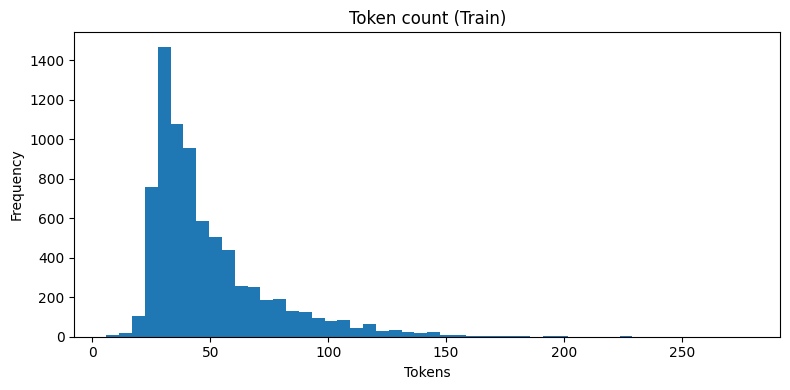

Token length percentiles (Train):


,percentile,token_count
0,50.0,41
1,75.0,57
2,90.0,84
3,95.0,103
4,97.0,116
5,98.0,125
6,99.0,141
7,99.5,155
8,99.9,196



Chosen MAX_LEN: 141


In [3]:
def token_count(text):
    return len(tokenizer(text, add_special_tokens=True, truncation=False)["input_ids"])

train_df["tok_len"] = train_df["text"].apply(token_count)

plt.figure(figsize=(8,4))
train_df["tok_len"].plot(kind='hist', bins=50, title="Token count (Train)")
plt.xlabel("Tokens"); plt.tight_layout(); plt.show()

percentiles = [50, 75, 90, 95, 97, 98, 99, 99.5, 99.9]
values = np.percentile(train_df["tok_len"], percentiles)
pct_df = pd.DataFrame({"percentile": percentiles, "token_count": values.astype(int)})
print("Token length percentiles (Train):")
display(pct_df)

def choose_max_len(lengths, pct=0.99, cap=512):
    thr = int(np.quantile(lengths, pct))
    return min(thr, cap)

MAX_LEN = choose_max_len(train_df["tok_len"].values, pct=0.99, cap=512)
print("\nChosen MAX_LEN:", MAX_LEN)


Aspect frequency (presence counts) — Train:


,aspect,count
0,BATTERY,3604
1,CAMERA,2123
2,DESIGN,1400
3,FEATURES,2472
4,GENERAL,4618
5,PERFORMANCE,4081
6,PRICE,951
7,SCREEN,927
8,SER&ACC,1743
9,STORAGE,92


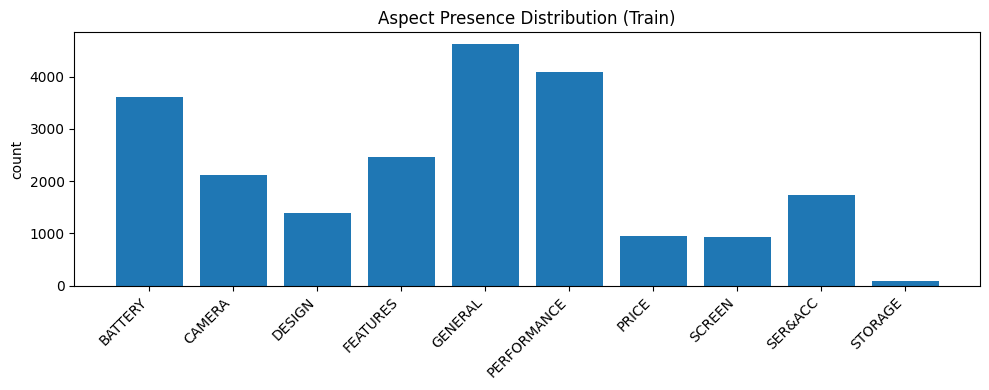

In [4]:
all_presence = np.stack(train_df["y_presence"].values)   # [N, A]
aspect_counts = all_presence.sum(axis=0)

eda_aspect_df = pd.DataFrame({
    "aspect": list(ASPECT_LIST.keys()),
    "count": aspect_counts.astype(int)
}).sort_values("aspect")

print("\nAspect frequency (presence counts) — Train:")
display(eda_aspect_df)

plt.figure(figsize=(10,4))
plt.bar(eda_aspect_df["aspect"], eda_aspect_df["count"])
plt.title("Aspect Presence Distribution (Train)")
plt.xticks(rotation=45, ha='right'); plt.ylabel("count"); plt.tight_layout()
plt.show()


Polarity distribution per aspect — Train:


,NEG,NEU,POS
BATTERY,1260,265,2079
CAMERA,636,265,1222
DESIGN,356,43,1001
FEATURES,1623,90,759
GENERAL,848,238,3532
PERFORMANCE,1605,243,2233
PRICE,211,227,513
SCREEN,392,41,494
SER&ACC,394,34,1315
STORAGE,18,17,57


<Figure size 1000x400 with 0 Axes>

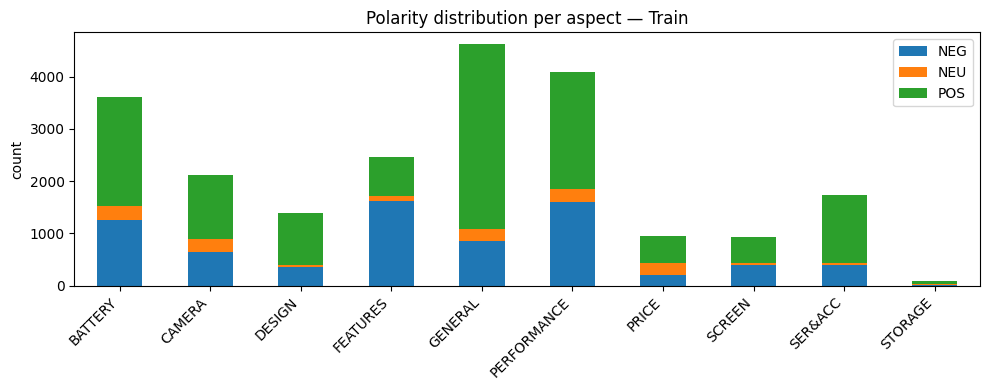

In [5]:
pol_mat = np.stack(train_df["y_polarity"].values)        # [N, A]
polarity_counts = {asp: {"NEG":0, "NEU":0, "POS":0} for asp in ASPECT_LIST.keys()}
for row in pol_mat:
    for asp, a_id in ASPECT_LIST.items():
        pid = row[a_id]
        if pid == -1: 
            continue
        if pid == 0: polarity_counts[asp]["NEG"] += 1
        elif pid == 1: polarity_counts[asp]["NEU"] += 1
        elif pid == 2: polarity_counts[asp]["POS"] += 1

pol_df = pd.DataFrame(polarity_counts).T.loc[sorted(ASPECT_LIST.keys())]
print("\nPolarity distribution per aspect — Train:")
display(pol_df)

plt.figure(figsize=(10,4))
pol_df.plot(kind='bar', stacked=True, figsize=(10,4), title="Polarity distribution per aspect — Train")
plt.ylabel("count"); plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.show()


In [6]:
def decode_aspect_and_polarity(row):
    aspects = []
    for a_name, a_id in ASPECT_LIST.items():
        if row["y_presence"][a_id] == 1:
            pol_id = row["y_polarity"][a_id]
            pol = {0:"NEGATIVE", 1:"NEUTRAL", 2:"POSITIVE"}.get(pol_id, "UNK")
            aspects.append(f"{a_name} -> {pol}")
    return aspects

def show_samples_for_aspect(df, aspect_name, k=3):
    a_id = ASPECT_LIST[aspect_name]
    sub = df[df["y_presence"].apply(lambda v: v[a_id] == 1)].head(k)

    rows = []
    for _, r in sub.iterrows():
        rows.append({
            "text": r["text"],
            "labels": decode_aspect_and_polarity(r)
        })
    return pd.DataFrame(rows)

for asp in ASPECT_LIST.keys():
    print(f"\n=== Samples for Aspect: {asp} ===")
    display(show_samples_for_aspect(train_df, asp, k=3))



=== Samples for Aspect: BATTERY ===


,text,labels
0,Pin Sài tầm 50h cho pin 100/100. Camera ổn ......,"[BATTERY -> POSITIVE, CAMERA -> POSITIVE, GENE..."
1,Lag và hao pin là cái tóm tắt về máy. S...,"[BATTERY -> NEGATIVE, GENERAL -> NEGATIVE, PER..."
2,Tất cả đều ổn ngoại trừ lúc máy nóng lên thì p...,"[BATTERY -> NEGATIVE, CAMERA -> NEUTRAL]"



=== Samples for Aspect: CAMERA ===


,text,labels
0,Pin Sài tầm 50h cho pin 100/100. Camera ổn ......,"[BATTERY -> POSITIVE, CAMERA -> POSITIVE, GENE..."
1,Tất cả đều ổn ngoại trừ lúc máy nóng lên thì p...,"[BATTERY -> NEGATIVE, CAMERA -> NEUTRAL]"
2,"Máy loa to ,bin trâu game lp tuy chỉ bựt đc fq...","[BATTERY -> POSITIVE, CAMERA -> NEUTRAL, FEATU..."



=== Samples for Aspect: DESIGN ===


...

,text,labels
0,"Máy màn hình lớn , nhận diện khuôn mặt nhanh (...","[BATTERY -> POSITIVE, FEATURES -> POSITIVE, PE..."
1,"Mình mua xài đc 1 tháng, Chụp hình đẹp, lỗi độ...","[CAMERA -> POSITIVE, FEATURES -> NEGATIVE, GEN..."
2,"Cái gì cũng tốt,nhất là pin trâu và thứ 2 là m...","[BATTERY -> POSITIVE, GENERAL -> POSITIVE, SCR..."



=== Samples for Aspect: SER&ACC ===


,text,labels
0,Pin Sài tầm 50h cho pin 100/100. Camera ổn ......,"[BATTERY -> POSITIVE, CAMERA -> POSITIVE, GENE..."
1,"Ok mua máy ở TGDD chính sách đổi trả rất tốt,r...",[SER&ACC -> POSITIVE]
2,"kiểu dáng thì đẹp,cầm chắc tay,nhưng loa nhỏ q...","[DESIGN -> POSITIVE, FEATURES -> NEGATIVE, SER..."



=== Samples for Aspect: STORAGE ===


,text,labels
0,Quảng cáo thì hay tới lúc hết bảo hành toàn lỗ...,"[DESIGN -> NEGATIVE, GENERAL -> NEGATIVE, STOR..."
1,"Mình mới mua cho cha mình hôm kia, bản 32Gb, v...","[BATTERY -> POSITIVE, FEATURES -> POSITIVE, GE..."
2,Máy làm j cũng ngon chiến game tốt chụp hình n...,"[CAMERA -> POSITIVE, GENERAL -> POSITIVE, PERF..."


In [7]:
class ABSASentDataset(torch.utils.data.Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = tokenizer(
            row["text"],
            truncation=True,
            max_length=MAX_LEN,   
            padding=False
        )
        return {
            "input_ids": torch.tensor(enc["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(enc["attention_mask"], dtype=torch.long),
            "y_presence": torch.tensor(row["y_presence"], dtype=torch.float32),  # [10] for BCE
            "y_polarity": torch.tensor(row["y_polarity"], dtype=torch.long),     # [10] with -1 mask
            "text": row["text"]
        }

def collate_sent(batch):
    max_len = max(len(x["input_ids"]) for x in batch)
    pad_id  = tokenizer.pad_token_id

    def pad1(t, padv):
        out = torch.full((max_len,), padv, dtype=t.dtype)
        out[:len(t)] = t
        return out

    return {
        "input_ids": torch.stack([pad1(x["input_ids"], pad_id) for x in batch]),
        "attention_mask": torch.stack([pad1(x["attention_mask"], 0) for x in batch]),
        "y_presence": torch.stack([x["y_presence"] for x in batch]),   # [B, 10]
        "y_polarity": torch.stack([x["y_polarity"] for x in batch]),   # [B, 10]
        "texts": [x["text"] for x in batch],
    }


BATCH_SIZE = 12  

train_loader = DataLoader(
    ABSASentDataset(train_df),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_sent
)
val_loader = DataLoader(
    ABSASentDataset(val_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_sent
)
test_loader = DataLoader(
    ABSASentDataset(test_df),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_sent
)

print("Sentence-level DataLoader ready. MAX_LEN =", MAX_LEN)

b = next(iter(train_loader))
print("Batch shapes:",
      b["input_ids"].shape,     # (B, L)
      b["y_presence"].shape,    # (B, A)
      b["y_polarity"].shape)    # (B, A)

Sentence-level DataLoader ready. MAX_LEN = 141
Batch shapes: torch.Size([12, 51]) torch.Size([12, 10]) torch.Size([12, 10])


In [8]:
class AspectGuidedAttention(nn.Module):
    def __init__(self, hidden_size: int, num_aspects: int, num_heads: int = 4):
        super().__init__()
        self.num_aspects = num_aspects
        self.hidden = hidden_size
        self.num_heads = num_heads

        # Query learned for per aspect: [A, H]
        self.aspect_queries = nn.Parameter(torch.randn(num_aspects, hidden_size))

        # 1 MultiheadAttention: query dim = key dim = value dim = H
        self.mha = nn.MultiheadAttention(
            embed_dim=hidden_size, num_heads=num_heads, batch_first=True
        )
        self.ln = nn.LayerNorm(hidden_size)

    def forward(self, token_feats, attn_mask):
        """
        token_feats: [B, L, H] từ backbone
        attn_mask:  [B, L]  (1=keep, 0=pad)
        return: aspect-specific summaries [B, A, H]
        """
        B, L, H = token_feats.shape
        # Query per batch: [B, A, H]
        Q = self.aspect_queries.unsqueeze(0).expand(B, self.num_aspects, H)

        mask_bool = (attn_mask == 0)  # [B, L], True = pad

        out, _ = self.mha(
            query=Q, key=token_feats, value=token_feats,
            key_padding_mask=mask_bool  # True = vị trí bị che
        )  # out: [B, A, H]

        # Residual + LN
        out = self.ln(out + Q)
        return out  # [B, A, H]

class SentenceABSA_AGA(nn.Module):
    def __init__(self, model_name, num_aspects, num_polarities, heads=4, dropout=0.15):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        H = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(dropout)

        self.aga = AspectGuidedAttention(H, num_aspects, num_heads=heads)

        # Head 1
        self.pres_head = nn.Linear(H, 1)                 # apply per aspect → squeeze(-1)
        # Head 2
        self.pol_head  = nn.Linear(H, num_polarities)    # apply per aspect

        self.num_aspects = num_aspects
        self.num_polarities = num_polarities

        #  CLS fusion: W*[CLS] + U*[h_aspect]
        self.fuse_cls = nn.Linear(2*H, H)

    def forward(self, input_ids, attention_mask):
        
        out = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        tok = out.last_hidden_state                 # [B, L, H]
        cls = tok[:, 0, :]                          # [B, H]

        
        h_aspect = self.aga(tok, attention_mask)    # [B, A, H]

        B, A, H = h_aspect.shape
        cls_exp = cls.unsqueeze(1).expand(B, A, H)  # [B, A, H]
        h = torch.cat([h_aspect, cls_exp], dim=-1)  # [B, A, 2H]
        h = self.dropout(self.fuse_cls(h))          # [B, A, H]

        # Head 1: presence (sigmoid )
        pres_logits = self.pres_head(h).squeeze(-1)       # [B, A]

        # Head 2: polarity (softmax )
        pol_logits  = self.pol_head(h)                    # [B, A, P]

        return pres_logits, pol_logits


num_aspects = len(ASPECT_LIST)      # 10
num_polarities = len(POL_LIST)      # 3

model = SentenceABSA_AGA(
    MODEL_NAME,
    num_aspects=num_aspects,
    num_polarities=num_polarities
).to(DEVICE)

print("Sentence-level ABSA model loaded. Backbone:", MODEL_NAME)


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Sentence-level ABSA model loaded. Backbone: xlm-roberta-large


In [10]:
pres_mat = np.stack(train_df["y_presence"].values)  # [N, A]
pos = pres_mat.sum(axis=0)                          # [A] số câu có aspect
neg = len(train_df) - pos                           # [A] số câu không có aspect

eps = 1e-6
pos_weight_np = (neg + eps) / (pos + eps)           # bigger weight for rare aspects
pos_weight_np = np.clip(pos_weight_np, a_min = None, a_max =10 )
print("pos counts:", pos.astype(int))
print("neg counts:", neg.astype(int))
print("pos_weight:", np.round(pos_weight_np, 3))

pos_weight = torch.tensor(pos_weight_np, dtype=torch.float32, device=DEVICE)

pos counts: [3604 2123 1400 2472 4618 4081  951  927 1743   92]
neg counts: [4004 5485 6208 5136 2990 3527 6657 6681 5865 7516]
pos_weight: [ 1.111  2.584  4.434  2.078  0.647  0.864  7.     7.207  3.365 10.   ]


In [11]:
bce_loss = nn.BCEWithLogitsLoss(pos_weight= pos_weight)
ce_loss  = nn.CrossEntropyLoss(reduction="none")

print("Loss functions ready.")


Loss functions ready.


In [12]:
SAVE_DIR = "./checkpoints_sentenceABSA_AGA"; os.makedirs(SAVE_DIR, exist_ok=True)
BEST_PATH = os.path.join(SAVE_DIR, "best_sentence.pt")


LR = 2e-5
EPOCHS = 6         
PATIENCE = 2        
optimizer = AdamW(model.parameters(), lr=LR)
total_steps = EPOCHS * len(train_loader)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, int(0.1 * total_steps)),
    num_training_steps=total_steps
)


def step_batch(batch, train=True):
    model.train(train)
    ids  = batch["input_ids"].to(DEVICE)
    mask = batch["attention_mask"].to(DEVICE)
    yP   = batch["y_presence"].to(DEVICE)   # [B, A] float
    yS   = batch["y_polarity"].to(DEVICE)   # [B, A] long (-1 mask)

    pres_logits, pol_logits = model(ids, mask)  # [B,A], [B,A,3]

    # Loss presence (multi-label)
    loss_pres = bce_loss(pres_logits, yP)

    # Loss polarity (masked CE)
    B, A, C = pol_logits.shape
    pol_flat = pol_logits.view(B*A, C)          # [B*A, 3]
    yS_flat  = yS.view(B*A)                     # [B*A]
    valid    = yS_flat >= 0
    loss_pol = torch.tensor(0.0, device=DEVICE)
    if valid.any():
        loss_pol = ce_loss(pol_flat[valid], yS_flat[valid]).mean()

    loss = loss_pres + loss_pol

    if train:
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step(); optimizer.zero_grad()

    return loss.item(), pres_logits.detach(), pol_logits.detach()

@torch.no_grad()
def predict_loader(loader):
    model.eval()
    all_P_gold=[]; all_P_pred=[]
    all_S_gold=[]; all_S_pred=[]

    for b in loader:
        loss, pres_logits, pol_logits = step_batch(b, train=False)
        # Presence
        yP = b["y_presence"].cpu().numpy().astype(int)                 # [B,A]
        pP = (torch.sigmoid(pres_logits).cpu().numpy() > 0.5).astype(int)
        all_P_gold.append(yP); all_P_pred.append(pP)

        # Polarity (only on gold-present)
        yS = b["y_polarity"].cpu().numpy()                             # [B,A] (-1 mask)
        pS = pol_logits.argmax(-1).cpu().numpy().astype(int)           # [B,A]
       
        mask_valid = (yS >= 0)
        yS_masked = np.where(mask_valid, yS, -1)
        pS_masked = np.where(mask_valid, pS, -1)
        all_S_gold.append(yS_masked)
        all_S_pred.append(pS_masked)

    pres_g = np.concatenate(all_P_gold, 0)   # [N,A]
    pres_p = np.concatenate(all_P_pred, 0)   # [N,A]
    pol_g  = np.concatenate(all_S_gold, 0)   # [N,A]
    pol_p  = np.concatenate(all_S_pred, 0)   # [N,A]

    # ---- Aspect-only ----
    # Micro (treat each aspect presence as binary label)
    a_microP, a_microR, a_microF1, _ = precision_recall_fscore_support(
        pres_g.reshape(-1), pres_p.reshape(-1), average='binary', zero_division=0
    )
    # Macro per-aspect
    macro_f1_list=[]
    for ai in range(pres_g.shape[1]):
        P,R,F1,_ = precision_recall_fscore_support(
            pres_g[:,ai], pres_p[:,ai], average='binary', zero_division=0
        )
        macro_f1_list.append(F1)
    a_macroF1 = float(np.mean(macro_f1_list)) if macro_f1_list else 0.0

    # ---- Polarity-only (macro-F1 on gold-present) ----
    p_macro_list=[]
    for ai in range(pol_g.shape[1]):
        mask = (pol_g[:,ai] >= 0)
        if mask.sum()==0: 
            continue
        P,R,F1,_ = precision_recall_fscore_support(
            pol_g[mask,ai], pol_p[mask,ai], average='macro', labels=[0,1,2], zero_division=0
        )
        p_macro_list.append(F1)
    p_macroF1 = float(np.mean(p_macro_list)) if p_macro_list else 0.0

    # ---- Combined F1 ----
    # TP: gold present & pred present & polarity predicted đúng
    comb_TP=comb_FP=comb_FN=0
    N, A = pres_g.shape
    for i in range(N):
        for ai in range(A):
            gold_present = (pres_g[i,ai] == 1)
            pred_present = (pres_p[i,ai] == 1)
            if gold_present and pred_present:
                # có gold polarity?
                if pol_g[i,ai] >= 0 and pol_p[i,ai] == pol_g[i,ai]:
                    comb_TP += 1
                else:
                    comb_FP += 1
            elif (not gold_present) and pred_present:
                comb_FP += 1
            elif gold_present and (not pred_present):
                comb_FN += 1
    if (comb_TP+comb_FP)>0 and (comb_TP+comb_FN)>0:
        comb_P = comb_TP/(comb_TP+comb_FP)
        comb_R = comb_TP/(comb_TP+comb_FN)
        comb_F1 = 2*comb_P*comb_R/(comb_P+comb_R) if (comb_P+comb_R)>0 else 0.0
    else:
        comb_P=comb_R=comb_F1=0.0

    return {
        "aspect_microP": a_microP,
        "aspect_microR": a_microR,
        "aspect_microF1": a_microF1,
        "aspect_macroF1": a_macroF1,
        "polarity_macroF1": p_macroF1,
        "combined_F1": comb_F1
    }




In [ ]:
best = -1.0
no_imp = 0

for ep in range(1, EPOCHS+1):
    model.train()
    run_loss = 0.0
    for step, batch in enumerate(train_loader, 1):
        loss, _, _ = step_batch(batch, train=True)
        run_loss += loss
        if step % 50 == 0:
            print(f"Epoch {ep} | step {step}/{len(train_loader)} | loss {run_loss/step:.4f}")
    print(f"Epoch {ep} train loss {run_loss/max(1,len(train_loader)):.4f}")

    metrics = predict_loader(val_loader)
    print(f"VAL — aspect_macroF1={metrics['aspect_macroF1']:.4f} | "
          f"polarity_macroF1={metrics['polarity_macroF1']:.4f} | "
          f"combined_F1={metrics['combined_F1']:.4f}")

    if metrics["combined_F1"] > best:
        best = metrics["combined_F1"]
        no_imp = 0
        torch.save(model.state_dict(), BEST_PATH)
        print("Saved best:", BEST_PATH)
    else:
        no_imp += 1
        if no_imp >= PATIENCE:
            print(f"Early stopping at epoch {ep}.")
            break


Epoch 1 | step 50/634 | loss 1.8961
Epoch 1 | step 100/634 | loss 1.8050
Epoch 1 | step 150/634 | loss 1.7310
Epoch 1 | step 200/634 | loss 1.6420
Epoch 1 | step 250/634 | loss 1.5878
Epoch 1 | step 300/634 | loss 1.5369
Epoch 1 | step 350/634 | loss 1.4994
Epoch 1 | step 400/634 | loss 1.4683
Epoch 1 | step 450/634 | loss 1.4429
Epoch 1 | step 500/634 | loss 1.4228
Epoch 1 | step 550/634 | loss 1.3884
Epoch 1 | step 600/634 | loss 1.3602
Epoch 1 train loss 1.3383
VAL — aspect_macroF1=0.2943 | polarity_macroF1=0.6171 | combined_F1=0.2516
Saved best: ./checkpoints_sentence/best_sentence.pt
Epoch 2 | step 50/634 | loss 0.8743
Epoch 2 | step 100/634 | loss 0.8533
Epoch 2 | step 150/634 | loss 0.8414
Epoch 2 | step 200/634 | loss 0.8259
Epoch 2 | step 250/634 | loss 0.8191
Epoch 2 | step 300/634 | loss 0.7997
Epoch 2 | step 350/634 | loss 0.7838
Epoch 2 | step 400/634 | loss 0.7678
Epoch 2 | step 450/634 | loss 0.7523
Epoch 2 | step 500/634 | loss 0.7417
Epoch 2 | step 550/634 | loss 0.734

In [14]:
def evaluate_tables_and_save(loader, split_name, save_dir="./metrics_sentence", thr=0.5):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()

    all_P_gold, all_P_pred = [], []
    all_S_gold,  all_S_pred = [], []

    with torch.no_grad():
        for b in loader:
            ids  = b["input_ids"].to(DEVICE)
            mask = b["attention_mask"].to(DEVICE)
            yP   = b["y_presence"].cpu().numpy().astype(int)  # [B,A]
            yS   = b["y_polarity"].cpu().numpy()              # [B,A] (-1)

            pres_logits, pol_logits = model(ids, mask)        # [B,A], [B,A,3]
            pP = (torch.sigmoid(pres_logits).cpu().numpy() > thr).astype(int)
            pS = pol_logits.argmax(-1).cpu().numpy().astype(int)

            all_P_gold.append(yP);  all_P_pred.append(pP)
            # mask polarity ở nơi gold absent
            yS_masked = np.where(yS >= 0, yS, -1)
            pS_masked = np.where(yS >= 0, pS, -1)
            all_S_gold.append(yS_masked); all_S_pred.append(pS_masked)

    pres_g = np.concatenate(all_P_gold, 0)  # [N,A]
    pres_p = np.concatenate(all_P_pred, 0)  # [N,A]
    pol_g  = np.concatenate(all_S_gold, 0)  # [N,A]
    pol_p  = np.concatenate(all_S_pred, 0)  # [N,A]

    A = pres_g.shape[1]
    aspect_names = [k for k,_ in sorted(ASPECT_LIST.items(), key=lambda x:x[1])]

    # -------- 1) Aspect Presence per-class --------
    rows_aspect = []
    macro_list_aspect = []
    for ai, asp in enumerate(aspect_names):
        P,R,F1,_ = precision_recall_fscore_support(
            pres_g[:,ai], pres_p[:,ai], average='binary', zero_division=0
        )
        sup = int(pres_g[:,ai].sum())
        rows_aspect.append([asp, sup, P, R, F1])
        macro_list_aspect.append(F1)
    df_aspect = pd.DataFrame(rows_aspect, columns=["class","support","precision","recall","f1"])
    aspect_macroF1 = float(np.mean(macro_list_aspect))
    a_microP, a_microR, a_microF1, _ = precision_recall_fscore_support(
        pres_g.reshape(-1), pres_p.reshape(-1), average='binary', zero_division=0
    )

    # -------- 2) Polarity on gold-present per aspect --------
    rows_polar = []
    macro_list_polar = []
    for ai, asp in enumerate(aspect_names):
        mask = (pol_g[:,ai] >= 0)
        sup = int(mask.sum())
        if sup == 0:
            rows_polar.append([asp, 0, 0.0, 0.0, 0.0]); continue
        Pm,Rm,Fm,_ = precision_recall_fscore_support(
            pol_g[mask,ai], pol_p[mask,ai], average='macro', labels=[0,1,2], zero_division=0
        )
        rows_polar.append([asp, sup, Pm, Rm, Fm])
        macro_list_polar.append(Fm)
    df_polar = pd.DataFrame(rows_polar, columns=["class","support_gold_present","precision_macro","recall_macro","f1_macro"])
    polarity_macroF1 = float(np.mean(macro_list_polar)) if macro_list_polar else 0.0

    # -------- 3) Joint detection (Aspect+Polarity) per aspect --------
    rows_joint = []
    joint_f1_list = []
    comb_TP=comb_FP=comb_FN=0
    for ai, asp in enumerate(aspect_names):
        tp=fp=fn=0
        for i in range(pres_g.shape[0]):
            gold_present = (pres_g[i,ai]==1)
            pred_present = (pres_p[i,ai]==1)
            if gold_present and pred_present:
                if pol_g[i,ai] >= 0 and pol_p[i,ai] == pol_g[i,ai]:
                    tp += 1
                else:
                    fp += 1
            elif (not gold_present) and pred_present:
                fp += 1
            elif gold_present and (not pred_present):
                fn += 1
        Pj = tp/(tp+fp) if (tp+fp)>0 else 0.0
        Rj = tp/(tp+fn) if (tp+fn)>0 else 0.0
        Fj = 2*Pj*Rj/(Pj+Rj) if (Pj+Rj)>0 else 0.0
        rows_joint.append([asp, tp+fp+fn, Pj, Rj, Fj])
        joint_f1_list.append(Fj)
        comb_TP+=tp; comb_FP+=fp; comb_FN+=fn
    df_joint = pd.DataFrame(rows_joint, columns=["class","support_pairs","precision","recall","f1"])
    joint_macroF1 = float(np.mean(joint_f1_list)) if joint_f1_list else 0.0
    if (comb_TP+comb_FP)>0 and (comb_TP+comb_FN)>0:
        joint_microP = comb_TP/(comb_TP+comb_FP)
        joint_microR = comb_TP/(comb_TP+comb_FN)
        joint_microF1= 2*joint_microP*joint_microR/(joint_microP+joint_microR) if (joint_microP+joint_microR)>0 else 0.0
    else:
        joint_microP = joint_microR = joint_microF1 = 0.0

    # -------- 4) Summary one-row table --------
    df_summary = pd.DataFrame([{
        "split": split_name,
        "datetime": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model": MODEL_NAME,
        "max_len": int(MAX_LEN),
        "batch_size": int(loader.batch_size) if hasattr(loader,"batch_size") else None,

        "aspect_microP": a_microP,
        "aspect_microR": a_microR,
        "aspect_microF1": a_microF1,
        "aspect_macroF1": aspect_macroF1,

        "polarity_macroF1": polarity_macroF1,

        "joint_microP": joint_microP,
        "joint_microR": joint_microR,
        "joint_microF1": joint_microF1,
        "joint_macroF1": joint_macroF1
    }])


    print(f"\n=== {split_name} — Aspect Presence (per class) ==="); display(df_aspect)
    print(f"\n=== {split_name} — Polarity on Gold (per aspect) ==="); display(df_polar)
    print(f"\n=== {split_name} — Joint Detection (per aspect) ==="); display(df_joint)
    print(f"\n=== {split_name} — Summary ==="); display(df_summary)


    p_aspect = os.path.join(save_dir, f"{split_name}_aspect_per_class.csv")
    p_polar  = os.path.join(save_dir, f"{split_name}_polarity_on_gold_per_aspect.csv")
    p_joint  = os.path.join(save_dir, f"{split_name}_joint_per_aspect.csv")
    p_sumcsv = os.path.join(save_dir, f"{split_name}_summary.csv")
    p_sumjson= os.path.join(save_dir, f"{split_name}_summary.json")

    df_aspect.to_csv(p_aspect, index=False)
    df_polar.to_csv(p_polar, index=False)
    df_joint.to_csv(p_joint, index=False)
    df_summary.to_csv(p_sumcsv, index=False)

    with open(p_sumjson, "w", encoding="utf-8") as f:
        json.dump(df_summary.iloc[0].to_dict(), f, indent=4, ensure_ascii=False)

    print("[Saved]", p_aspect)
    print("[Saved]", p_polar)
    print("[Saved]", p_joint)
    print("[Saved]", p_sumcsv)
    print("[Saved]", p_sumjson)

    return df_aspect, df_polar, df_joint, df_summary


In [15]:
model.load_state_dict(torch.load(BEST_PATH))
_ = evaluate_tables_and_save(test_loader, split_name="test",save_dir ="./metrics_sentenceABSA_AGA")



=== test — Aspect Presence (per class) ===


,class,support,precision,recall,f1
0,BATTERY,1017,0.980178,0.972468,0.976308
1,CAMERA,585,0.934783,0.955556,0.945055
2,DESIGN,375,0.841727,0.936000,0.886364
3,FEATURES,729,0.888740,0.909465,0.898983
4,GENERAL,1333,0.906708,0.882221,0.894297
5,PERFORMANCE,1166,0.923144,0.906518,0.914756
6,PRICE,252,0.668639,0.896825,0.766102
7,SCREEN,258,0.840580,0.899225,0.868914
8,SER&ACC,489,0.842829,0.877301,0.859719
9,STORAGE,34,0.615385,0.705882,0.657534



=== test — Polarity on Gold (per aspect) ===


,class,support_gold_present,precision_macro,recall_macro,f1_macro
0,BATTERY,1017,0.768284,0.771505,0.769788
1,CAMERA,585,0.862296,0.869657,0.865793
2,DESIGN,375,0.841458,0.712223,0.748033
3,FEATURES,729,0.823380,0.796359,0.808260
4,GENERAL,1333,0.831721,0.818393,0.824791
5,PERFORMANCE,1166,0.782319,0.753134,0.765606
6,PRICE,252,0.794478,0.784981,0.786103
7,SCREEN,258,0.729675,0.750438,0.738653
8,SER&ACC,489,0.969212,0.739129,0.798460
9,STORAGE,34,0.944444,0.857143,0.878788



=== test — Joint Detection (per aspect) ===


,class,support_pairs,precision,recall,f1
0,BATTERY,1037,0.885035,0.969598,0.925389
1,CAMERA,624,0.857860,0.951763,0.902375
2,DESIGN,441,0.786571,0.931818,0.853056
3,FEATURES,812,0.836461,0.904348,0.869081
4,GENERAL,1454,0.865073,0.877248,0.871118
5,PERFORMANCE,1254,0.845415,0.898793,0.871287
6,PRICE,364,0.556213,0.878505,0.681159
7,SCREEN,302,0.797101,0.894309,0.842912
8,SER&ACC,569,0.815324,0.873684,0.843496
9,STORAGE,49,0.589744,0.696970,0.638889



=== test — Summary ===


,split,datetime,model,max_len,batch_size,aspect_microP,aspect_microR,aspect_microF1,aspect_macroF1,polarity_macroF1,joint_microP,joint_microR,joint_microF1,joint_macroF1
0,test,2025-11-11 16:24:20,xlm-roberta-large,141,12,0.895199,0.914716,0.904853,0.866803,0.798428,0.830562,0.908685,0.867869,0.829876


[Saved] ./metrics_sentenceABSA_AGA/test_aspect_per_class.csv
[Saved] ./metrics_sentenceABSA_AGA/test_polarity_on_gold_per_aspect.csv
[Saved] ./metrics_sentenceABSA_AGA/test_joint_per_aspect.csv
[Saved] ./metrics_sentenceABSA_AGA/test_summary.csv
[Saved] ./metrics_sentenceABSA_AGA/test_summary.json


In [16]:
ASPECT_NAMES = [k for k,_ in sorted(ASPECT_LIST.items(), key=lambda x: x[1])]
POL_NAMES    = [k for k,_ in sorted(POL_LIST.items(),    key=lambda x: x[1])]

@torch.no_grad()
def infer_one(text: str, thr_vec=None, topk=None):
   
    model.eval()
    enc = tokenizer(text, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(DEVICE)
    pres_logits, pol_logits = model(enc["input_ids"], enc["attention_mask"])   # [1,A], [1,A,3]

    pres_prob = torch.sigmoid(pres_logits).squeeze(0).cpu().numpy()            # [A]
    pol_prob  = torch.softmax(pol_logits, dim=-1).squeeze(0).cpu().numpy()     # [A,3]

    A = len(ASPECT_NAMES)
    if thr_vec is None:
        thr_vec = np.full((A,), 0.5, dtype=float)

    results = []
    for ai, asp in enumerate(ASPECT_NAMES):
        present = pres_prob[ai] > thr_vec[ai]
        pred_pol_id = int(pol_prob[ai].argmax())
        pred_pol = POL_NAMES[pred_pol_id]
        item = {
            "aspect": asp,
            "sentiment": pred_pol if present else "NONE",   
            "presence_prob": float(pres_prob[ai]),
            "polarity_probs": {POL_NAMES[j]: float(pol_prob[ai, j]) for j in range(len(POL_NAMES))},
            "score": float(pres_prob[ai] * pol_prob[ai].max()),
            "present": bool(present)
        }
       
        if present:
            results.append(item)

   
    results.sort(key=lambda d: d["score"], reverse=True)

    if topk is not None:
        results = results[:topk]

    return results


@torch.no_grad()
def infer_batch(texts, thr_vec=None, topk=None):

    outputs = []
    for t in texts:
        outputs.append(infer_one(t, thr_vec=thr_vec, topk=topk))
    return outputs



In [17]:

sample_text = "Pin trâu, máy mượt nhưng camera hơi mờ. Giá thì cũng được."
pred = infer_one(sample_text)  
print(sample_text)
for r in pred:
    print(f"- {r['aspect']} -> {r['sentiment']} | presence={r['presence_prob']:.2f} | score={r['score']:.2f}")


Pin trâu, máy mượt nhưng camera hơi mờ. Giá thì cũng được.
- BATTERY -> POSITIVE | presence=1.00 | score=0.99
- PERFORMANCE -> POSITIVE | presence=0.99 | score=0.98
- CAMERA -> NEGATIVE | presence=1.00 | score=0.94
- PRICE -> NEUTRAL | presence=0.98 | score=0.64


In [18]:
sample_text_2 = "Máy đẹp, pin trâu nhưng màn hơi ám vàng."
pred2 = infer_one(sample_text_2) 
print(sample_text_2)
for r in pred2:
    print(f"- {r['aspect']} -> {r['sentiment']} | presence={r['presence_prob']:.2f} | score={r['score']:.2f}")


Máy đẹp, pin trâu nhưng màn hơi ám vàng.
- DESIGN -> POSITIVE | presence=1.00 | score=0.99
- BATTERY -> POSITIVE | presence=1.00 | score=0.99
- SCREEN -> NEGATIVE | presence=1.00 | score=0.98
